In [ ]:
#---------------------------------------------
# Step 1: Environment Setup & Torchvision Imports
#---------------------------------------------

In [1]:
import torch
import torchvision
from torchvision import transforms, models
from torchvision.datasets import VOCDetection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# Verify GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
#---------------------------------------------
# Step 2: Load the Pre-trained Faster R-CNN Model
#---------------------------------------------

In [2]:
# Load pre-trained Faster R-CNN model on COCO dataset
model = models.detection.fasterrcnn_resnet50_fpn(weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

# Move model to GPU and set to evaluation mode
model = model.to(device)
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 139MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
#---------------------------------------------
# Step 3: Define COCO Class Labels
#---------------------------------------------

In [3]:
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

In [ ]:
#---------------------------------------------
# Step 4: Define Image Preprocessing Pipeline
#---------------------------------------------

In [4]:
# Transform function for inference
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.ToTensor() # Converts PIL Image (0-255) to Tensor (0.0-1.0)
    ])
    return transform(image)

In [ ]:
#---------------------------------------------
# Step 5: Upload Image & Perform Object Detection
#---------------------------------------------

Upload an image for object detection:


Saving object-detector-5.jpg to object-detector-5.jpg


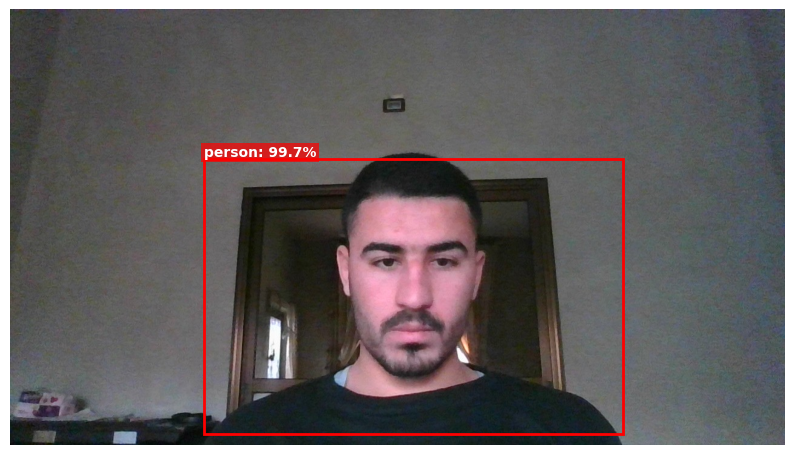


--- Detected Objects in object-detector-5.jpg ---
• person (99.68%) at [[ 319  247 1011  701]]


In [11]:
from google.colab import files
import io

print("Upload an image for object detection:")
uploaded = files.upload()

score_threshold = 0.5  # Only display detections with confidence >= 50%

for filename in uploaded.keys():
    # 1. Load Image
    raw_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

    # 2. Preprocess & Add Batch Dimension -> Shape: [1, 3, H, W]
    input_tensor = preprocess_image(raw_image).unsqueeze(0).to(device)

    # 3. Model Inference
    with torch.no_grad():
        predictions = model(input_tensor)[0]

    # Predictions dictionary contains:
    # 'boxes': Tensor of shape (N, 4) -> [xmin, ymin, xmax, ymax]
    # 'labels': Tensor of shape (N,) -> Class indices
    # 'scores': Tensor of shape (N,) -> Confidence scores (0.0 to 1.0)

    boxes = predictions['boxes'].cpu().numpy()
    labels = predictions['labels'].cpu().numpy()
    scores = predictions['scores'].cpu().numpy()

    # 4. Filter Predictions by Score Threshold
    valid_indices = np.where(scores >= score_threshold)[0]

    # 5. Plot Image and Draw Bounding Boxes
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(raw_image)

    for idx in valid_indices:
        box = boxes[idx]
        label_idx = labels[idx]
        score = scores[idx]

        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin

        # Create a red rectangle patch
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        # Format label text: Class Name (Confidence %)
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label_idx]
        caption = f"{class_name}: {score*100:.1f}%"

        # Display text label above bounding box
        ax.text(
            xmin, ymin - 5, caption,
            color='white', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=2)
        )

    plt.axis("off")
    plt.show()

    # Print summary text of detected objects
    print(f"\n--- Detected Objects in {filename} ---")
    for idx in valid_indices:
        print(f"• {COCO_INSTANCE_CATEGORY_NAMES[labels[idx]]} ({scores[idx]*100:.2f}%) at [{boxes[idx].astype(int)}]")